In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [24]:
CUR = "DTI Current-data-as-joinbyfield-2026-08-19 22_41_26.csv"
VOL = "DTI Voltage-data-2026-08-19 22_38_55.csv"

# na_values is required: the current export contains "undefined" sentinels, and
# without it pandas types DC/AC Current as StringDtype instead of float64.
current_df = pd.read_csv(CUR, encoding="utf-8-sig", na_values=["undefined"])
voltage_df = pd.read_csv(VOL, encoding="utf-8-sig", na_values=["undefined"])

current_df = current_df.sort_values("time").reset_index(drop=True)
voltage_df = voltage_df.sort_values("time").reset_index(drop=True)

print(current_df.shape, current_df.dtypes.to_dict())
print(voltage_df.shape, voltage_df.dtypes.to_dict())
display(current_df.head(3), voltage_df.head(3))

(70614, 3) {'time': dtype('int64'), 'DC Current': dtype('float64'), 'AC Current': dtype('float64')}
(70609, 2) {'DTI Voltage': dtype('int64'), 'time': dtype('int64')}


,time,DC Current,AC Current
0,1786825500007,0.0,0.0
1,1786825500033,0.0,0.0
2,1786825500059,0.0,0.0


,DTI Voltage,time
0,0,1786825500007
1,0,1786825500033
2,0,1786825500059


In [25]:
# Diagnostic: how far is each voltage sample from the nearest current sample?
# A single sharp spike (not a spread) means a constant sub-ms skew quantized to
# integer ms, rather than random jitter or a bad join.
tc = current_df["time"].to_numpy()
tv = voltage_df["time"].to_numpy()

j = np.clip(np.searchsorted(tc, tv), 1, len(tc) - 1)
left, right = tc[j - 1], tc[j]
near = np.where(np.abs(tv - left) <= np.abs(tv - right), left, right)
delta = pd.Series(tv - near)

print("voltage - nearest current (ms):")
print(delta.value_counts().sort_index())
print(f"\nexact matches: {(delta == 0).sum()} / {len(delta)} ({(delta == 0).mean():.1%})")
print(f"implied skew from the -1 fraction: {(delta == -1).mean() * 1e3:.0f} us")

voltage - nearest current (ms):
-2       15
-1    19703
 0    50891
Name: count, dtype: int64

exact matches: 50891 / 70609 (72.1%)
implied skew from the -1 fraction: 279 us


In [26]:
# The source emits a handful of repeated current samples: identical DC and AC
# readings 1 ms apart. Drop them before joining or they corrupt rate estimates
# and each claim the same voltage reading.
rep = ((current_df["time"].diff() < 2)
       & (current_df["DC Current"].diff() == 0)
       & (current_df["AC Current"].diff() == 0))

print(f"repeated current samples dropped: {rep.sum()}")
print(current_df.loc[rep, "time"].tolist())

current_df = current_df.loc[~rep].reset_index(drop=True)

repeated current samples dropped: 2
[1786825879461, 1786827535315]


In [27]:
# Tolerance join on the current clock. Grafana's join-by-field matches
# timestamps exactly, so the ~0.3 ms skew splits 28% of samples across two rows;
# merge_asof with a 2 ms tolerance collapses them back.
#
# tolerance=2 is load-bearing: without it, direction="nearest" pairs samples
# across the multi-second data gaps instead of leaving NaN.
voltage_df["v_idx"] = voltage_df.index

merged_df = pd.merge_asof(current_df, voltage_df, on="time",
                          direction="nearest", tolerance=2)

# merge_asof can hand the same right-hand row to several left-hand rows, so keep
# only the closest claimant for each voltage sample.
gap = (merged_df["time"] - merged_df["v_idx"].map(voltage_df["time"])).abs()
matched = merged_df["v_idx"].notna()
keep = (merged_df[matched].assign(_gap=gap)
        .sort_values("_gap").drop_duplicates("v_idx").index)

merged_df.loc[matched & ~merged_df.index.isin(keep), ["DTI Voltage", "v_idx"]] = np.nan
merged_df = merged_df.drop(columns="v_idx")

# Raw epoch ms is UTC; convert so timestamps match the Grafana dashboard.
merged_df["time"] = (pd.to_datetime(merged_df["time"], unit="ms", utc=True)
                       .dt.tz_convert("America/New_York"))

In [28]:
# Validate the join
dt = merged_df["time"].diff().dt.total_seconds() * 1e3

print(f"rows: {len(merged_df)}")
print(f"voltage placed: {merged_df['DTI Voltage'].notna().sum()} of {len(voltage_df)}")
print(f"median spacing: {dt.median():.1f} ms")
print(f"sub-2ms steps remaining: {(dt < 2).sum()}")
print(f"NaN counts: {merged_df.isna().sum().to_dict()}")

display(merged_df.head())

print("\nrows with any missing channel (genuine dropouts):")
display(merged_df[merged_df.isna().any(axis=1)])

rows: 70612
voltage placed: 70609 of 70609
median spacing: 26.0 ms
sub-2ms steps remaining: 0
NaN counts: {'time': 0, 'DC Current': 1, 'AC Current': 1, 'DTI Voltage': 3}


,time,DC Current,AC Current,DTI Voltage
0,2026-08-15 16:25:00.007000-04:00,0.0,0.0,0.0
1,2026-08-15 16:25:00.033000-04:00,0.0,0.0,0.0
2,2026-08-15 16:25:00.059000-04:00,0.0,0.0,0.0
3,2026-08-15 16:25:00.085000-04:00,0.0,0.0,0.0
4,2026-08-15 16:25:00.112000-04:00,0.0,0.0,0.0



rows with any missing channel (genuine dropouts):


,time,DC Current,AC Current,DTI Voltage
26245,2026-08-15 16:36:58.513000-04:00,0.0,NaN,NaN
26249,2026-08-15 16:36:59.738000-04:00,0.0,0.0,NaN
44229,2026-08-15 16:46:57.128000-04:00,NaN,12.3,480.0
44230,2026-08-15 16:46:57.154000-04:00,2.5,13.6,NaN


In [29]:
merged_df.interpolate(method="linear", inplace=True)

,time,DC Current,AC Current,DTI Voltage
0,2026-08-15 16:25:00.007000-04:00,0.0,0.0,0.0
1,2026-08-15 16:25:00.033000-04:00,0.0,0.0,0.0
2,2026-08-15 16:25:00.059000-04:00,0.0,0.0,0.0
3,2026-08-15 16:25:00.085000-04:00,0.0,0.0,0.0
4,2026-08-15 16:25:00.112000-04:00,0.0,0.0,0.0
...,...,...,...,...
70607,2026-08-15 16:59:59.874000-04:00,0.0,0.0,0.0
70608,2026-08-15 16:59:59.900000-04:00,0.0,0.0,0.0
70609,2026-08-15 16:59:59.926000-04:00,0.0,0.0,0.0
70610,2026-08-15 16:59:59.952000-04:00,0.0,0.0,0.0


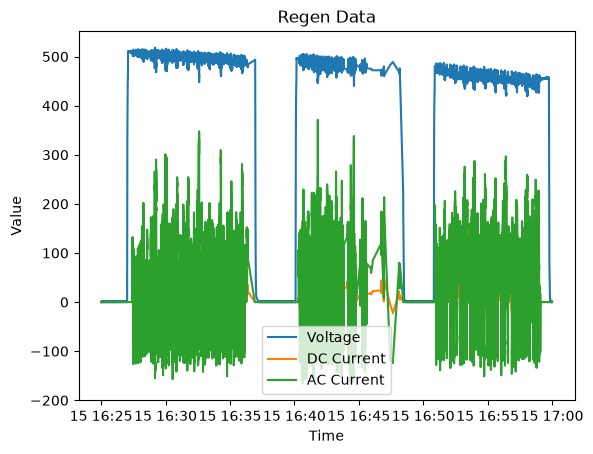

In [32]:
plt.Figure()
plt.plot(merged_df["time"], merged_df["DTI Voltage"], label="Voltage")
plt.plot(merged_df["time"], merged_df["DC Current"], label="DC Current")
plt.plot(merged_df["time"], merged_df["AC Current"], label="AC Current")
plt.xlabel("Time")
plt.ylabel("Value")
plt.title("Regen Data")
plt.legend()
plt.show()

In [ ]:
merged_df['Power'] = merged_df['DTI Voltage'] * merged_df['DC Current']

In [39]:
# Energy is the integral of power, so each sample's dt has to be applied to that
# sample's power *before* accumulating: cumsum(P * dt), not cumsum(P) * dt.
#
# Trapezoidal rather than rectangular: at 26 ms spacing the difference is small,
# but the 25 multi-second telemetry gaps are integrated as a ramp between the
# power on either side instead of a step held at one endpoint.
dt = merged_df["time"].diff().dt.total_seconds()
p = merged_df["Power"]

dE = 0.5 * (p + p.shift()) * dt          # J per interval; NaN on the first row
merged_df["Energy"] = dE.fillna(0).cumsum()

# The gaps still carry real weight: 255 s of the 2100 s record has no samples,
# and interpolating across it is an assumption, not a measurement. Report its
# share so the total can be read with that in mind.
GAP_S = 0.1
gap = dt > GAP_S

print(f"net energy:      {merged_df['Energy'].iloc[-1] / 3.6e6:+.3f} kWh")
print(f"  drawn:         {dE.clip(lower=0).sum() / 3.6e6:.3f} kWh")
print(f"  regenerated:   {-dE.clip(upper=0).sum() / 3.6e6:.3f} kWh")
print(f"\nintervals > {GAP_S * 1e3:.0f} ms: {gap.sum()} spanning {dt[gap].sum():.0f} s")
print(f"energy attributed to them: {dE[gap].sum() / 3.6e6:+.3f} kWh "
      f"({abs(dE[gap].sum() / dE.fillna(0).sum()):.0%} of net)")


net energy:      +2.911 kWh
  drawn:         3.219 kWh
  regenerated:   0.308 kWh

intervals > 100 ms: 25 spanning 255 s
energy attributed to them: +0.406 kWh (14% of net)


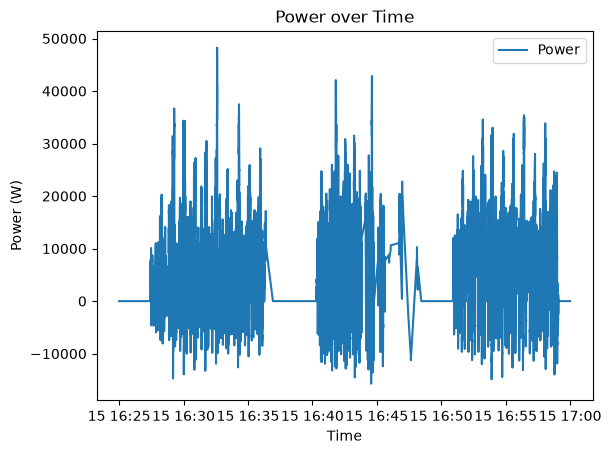

In [40]:
plt.Figure()
plt.plot(merged_df["time"], merged_df['Power'], label="Power")
plt.xlabel("Time")
plt.ylabel("Power (W)")
plt.title("Power over Time")
plt.legend()
plt.show()

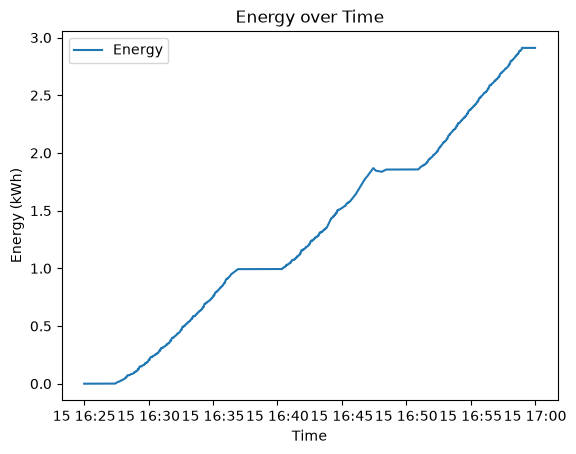

In [41]:
plt.Figure()
plt.plot(merged_df["time"], merged_df['Energy']/3.6e6, label="Energy")
plt.xlabel("Time")
plt.ylabel("Energy (kWh)")
plt.title("Energy over Time")
plt.legend()
plt.show()